<a href="https://colab.research.google.com/github/xtianu/CV_Tirana/blob/main/M1_Image%20Processing/Exercise%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 1: IMAGE PREPROCESSING

Module 1: Image Preprocessing
Christian Mata, PhD

# Exercise 1

**Before starting:**

- Create a GitHub repository to upload the solution of this exercise.
- Share this GitHub link to your professor.

**Objectives**

Generate a single Python notebook implementing and answering the following questions:

**- Task 1:** Load the built-in image 'coffee' of the skimage libraries. Details can be found at https://scikit-image.org/docs/stable/auto_examples/data/plot_general.html#sphx-glr-auto-examples-data-plot-general-py

**- Task 2:** Use the skimage function random_noise to add each of the 7 different types of noise available and generate a 4x2 panel figure with the original image and the 7 corrupted versions. The noise types are:

* ‘gaussian’ Gaussian-distributed additive noise.
* ‘localvar’ Gaussian-distributed additive noise, with specified
local variance at each point of image.
* ‘poisson’ Poisson-distributed noise generated from the data.
* ‘salt’ Replaces random pixels with 1.
* ‘pepper’ Replaces random pixels with 0 (for unsigned images) or
-1 (for signed images).
* ‘s&p’ Replaces random pixels with either 1 or low_val, where
low_val is 0 for unsigned images or -1 for signed images.
* ‘speckle’ Multiplicative noise using out = image + n*image, where
n is Gaussian noise with specified mean & variance.

Documentation of the function can be found at
https://scikit-image.org/docs/stable/api/skimage.util.html#skimage.util.random_noise

**- Task 3:** Select one of the noise types and generate 3 noisy images with different noise intensity levels. Represent the original image along with them in a 2x2 figure.

**- Task 4:**The standard deviation for Gaussian kernel affects the behavior of the gaussian filter (parameter sigma, see documentation https://scikit-image.org/docs/stable/api/skimage.filters.html#skimage.filters.gaussian). Explore the effect of the parameter sigma when applying a gaussian filter to the tree noisy images generated in the previus task. Represent and comment the results.

**- Task 5:** Detect the edges of the bricks in the built-in image 'bricks' using a Prewitt edge detection filter. Quantify what is the fraction of the image corresponding to bricks and to edges.

**- Task 6:** Apply a high-pass filter and a low-pass filter in the frequency domain to the skimage built-in image 'grass'. Represent the results and discuss the correspondance between spatial patterns in the original image and high/low frequency components of its the Fourier transform.

**- Task 7:** Use the function binary_blobs to generate an image with random blobs: https://scikit-image.org/docs/stable/api/skimage.data.html#skimage.data.binary_blobs
How many consecutive morphological erosions are needed in order to remove all the blobs? Use a disk-shaped structuring element of radius 3 pixels (footprint).  
https://scikit-image.org/docs/stable/api/skimage.morphology.html#skimage.morphology.disk




**Task 1**

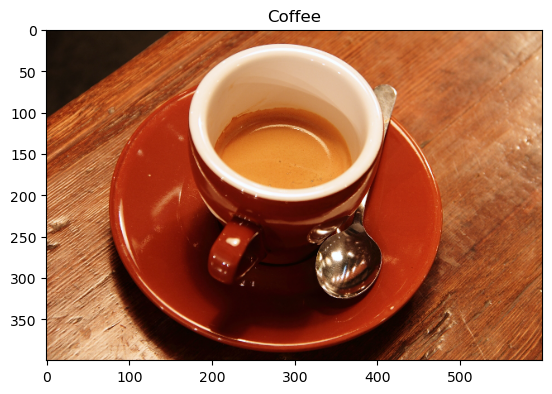

In [25]:
import skimage as sk
from skimage.io import imread
import matplotlib.pyplot as plt
import numpy as np


caller = getattr(sk.data, "coffee")
img = caller()

plt.title("Coffee")
plt.imshow(img)
plt.show()

**Task 2**

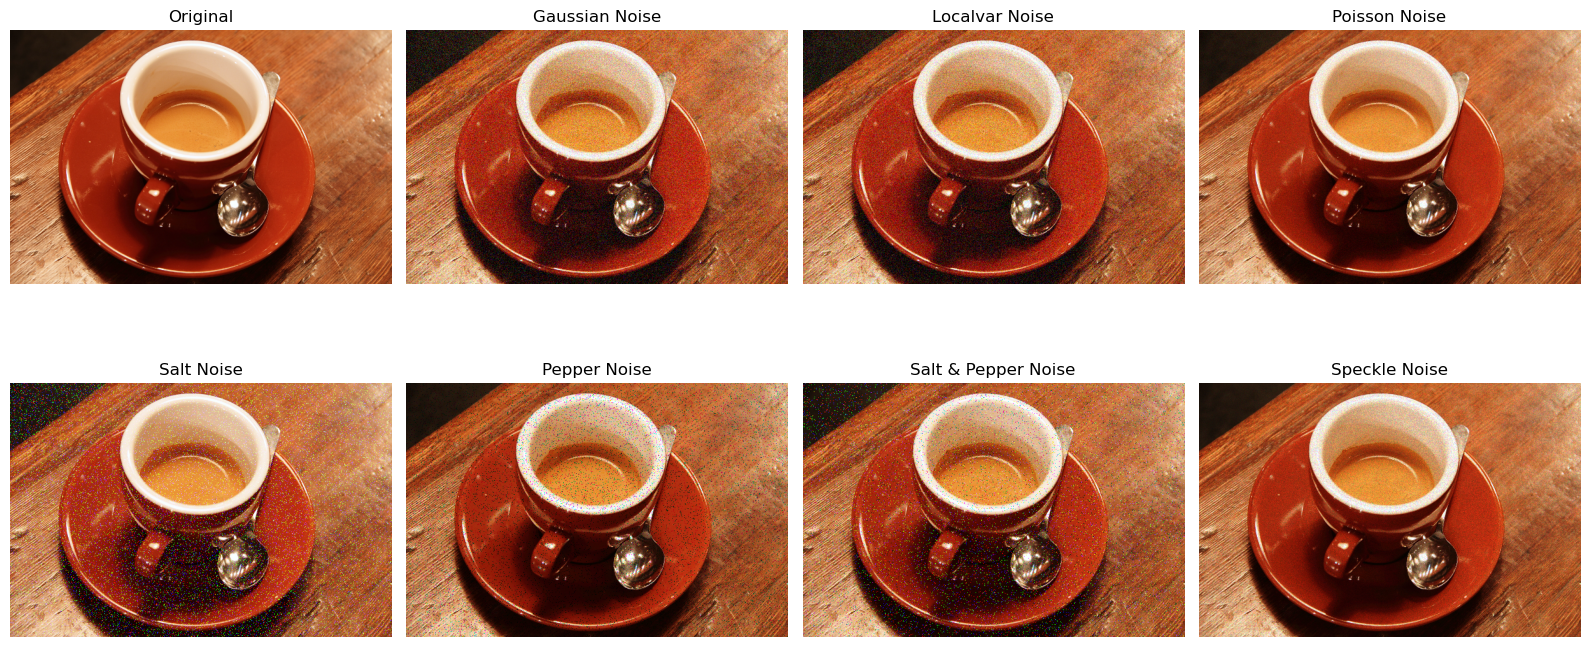

In [ ]:
import matplotlib.pyplot as plt
import skimage as sk

# Generate noisy versions of the same image using different noise types
img_gaussian = sk.util.random_noise(img, mode="gaussian")
img_localvar = sk.util.random_noise(img,mode="localvar")
img_poisson = sk.util.random_noise(img, mode="poisson")
img_salt = sk.util.random_noise(img, mode="salt")
img_pepper = sk.util.random_noise(img, mode="pepper")
img_sp = sk.util.random_noise(img, mode="s&p")
img_speckle = sk.util.random_noise(img, mode="speckle")

images = [
    img,
    img_gaussian,
    img_localvar,
    img_poisson,
    img_salt,
    img_pepper,
    img_sp,
    img_speckle
]

titles = [
    "Original",
    "Gaussian Noise",
    "Localvar Noise",
    "Poisson Noise",
    "Salt Noise",
    "Pepper Noise",
    "Salt & Pepper Noise",
    "Speckle Noise"
]


fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for ax, im, title in zip(axes, images, titles):
    ax.imshow(im)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

**Task 3:** noise chosen = "salt and pepper".  
According to the documentation, we can use the parameter 'amount' to control the amount of noise added to the image. The default value is 0.05, which means that 5% of the pixels will be affected by noise. We can increase this value to add more noise to the image, or decrease it to add less noise.


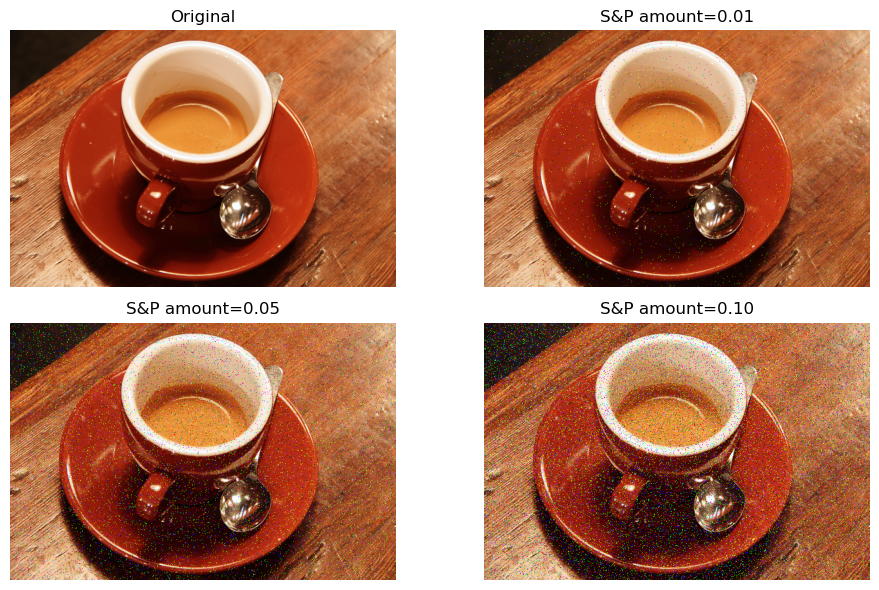

In [39]:
#3 S&P noise images with different amounts
amounts = [0.01, 0.05, 0.1]

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.ravel()

images = [img] + [sk.util.random_noise(img, mode="s&p", amount=a) for a in amounts]
titles = ["Original"] + [f"S&P amount={a:.2f}" for a in amounts]

for ax, im, title in zip(axes, images, titles):
  ax.imshow(im)
  ax.set_title(title)
  ax.axis("off")

plt.tight_layout()
plt.show()


**Task 4:** The parameter sigma controls the strength of the Gaussian smoothing.  
- For small sigma values, such as sigma=0.5, the filter slightly smooths the image.
Some salt-and-pepper noise is reduced, but many noisy pixels are still visible.  
- For medium sigma values, such as sigma=1 or sigma=2, the noise is reduced more clearly. However, the image also starts losing sharp details.
- For large sigma values, such as sigma=4, the image becomes very blurred.
Most of the noise is smoothed, but edges and fine details are strongly lost.

When the noise amount is higher, for example amount=0.1, a larger sigma is needed to reduce the noise. However, increasing sigma too much causes excessive blurring.

So there is a trade-off:
*higher sigma removes more noise, but also removes more image details.*

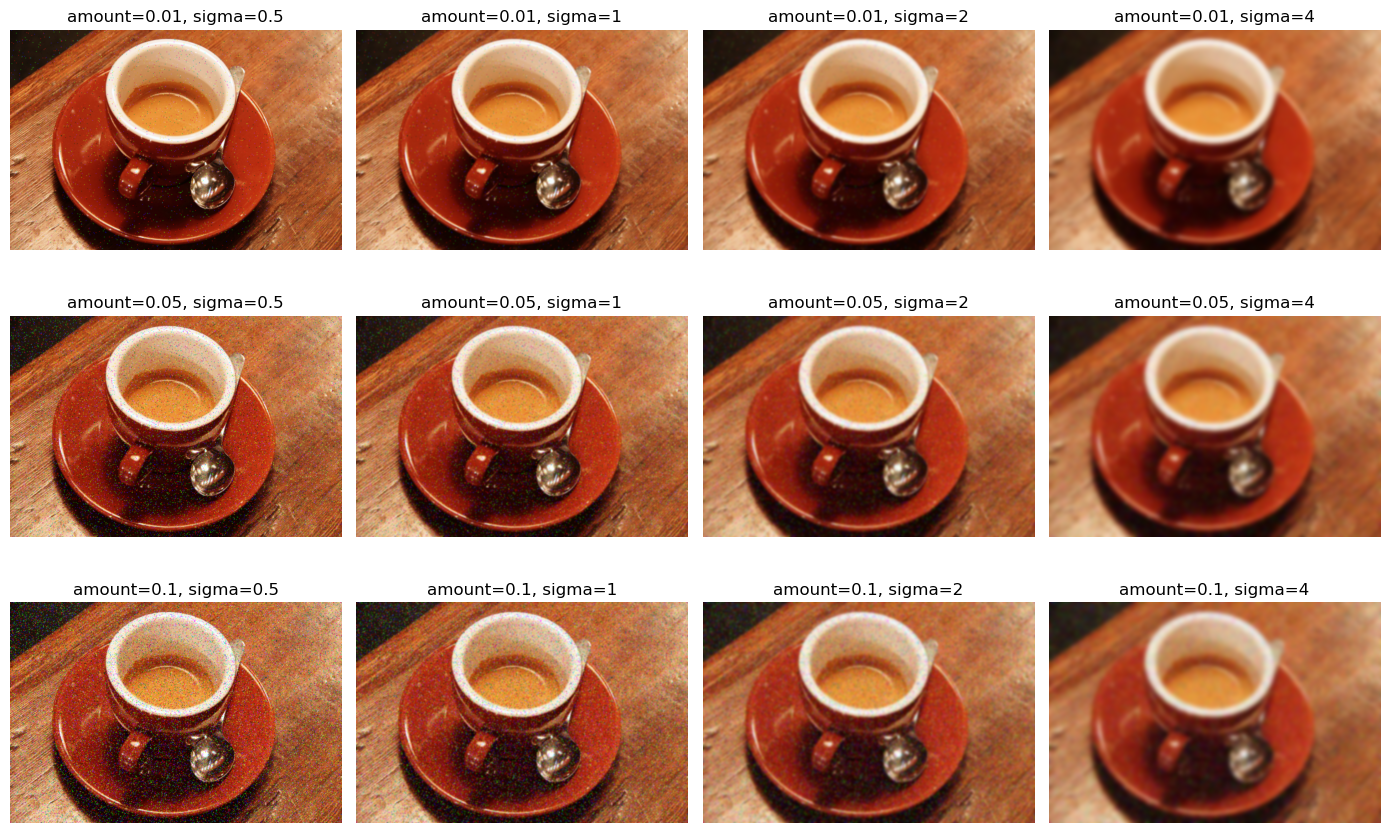

In [ ]:
from skimage.filters import gaussian
amounts = [0.01, 0.05, 0.1]

noisy_images = [sk.util.random_noise(img, mode="s&p", amount=a) for a in amounts]

# Different sigma values to test
sigmas = [0.5, 1, 2, 4]

fig, axes = plt.subplots(len(noisy_images), len(sigmas), figsize=(14, 9))

for i, noisy_img in enumerate(noisy_images):
    for j, sigma in enumerate(sigmas):

        # Apply Gaussian filter
        filtered_img = gaussian(noisy_img, sigma=sigma, channel_axis=-1)

        axes[i, j].imshow(filtered_img)
        axes[i, j].set_title(f"amount={amounts[i]}, sigma={sigma}")
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()

**Task 5**

Fraction of image corresponding to edges: 0.2117
Fraction of image corresponding to bricks/non-edges: 0.7883


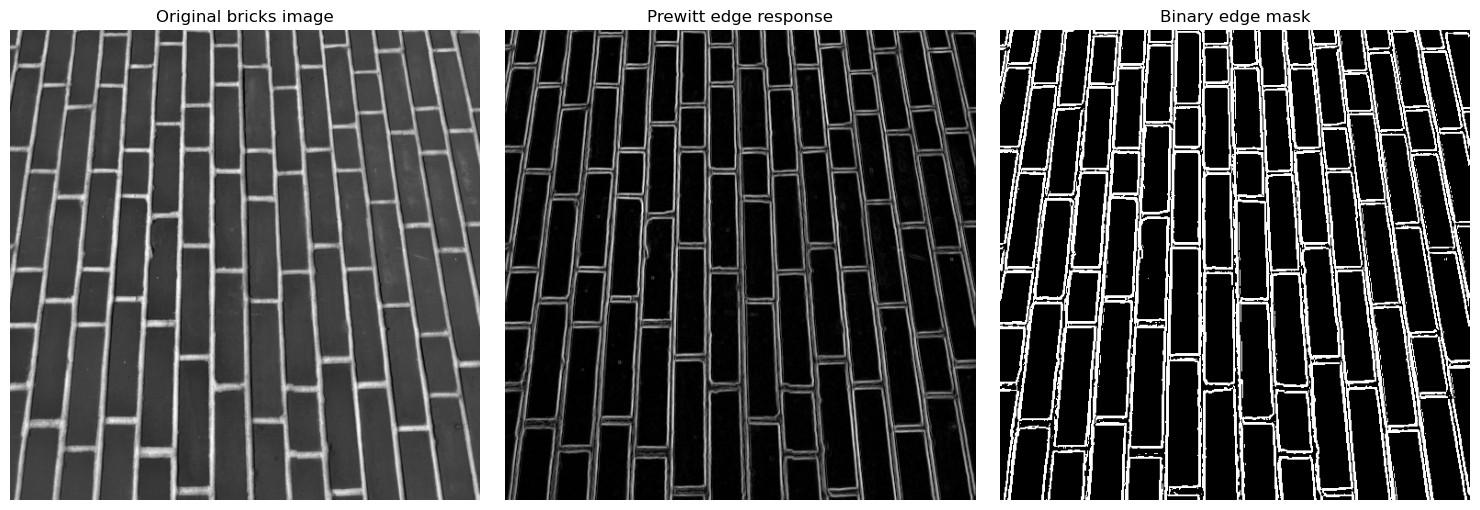

In [ ]:
from skimage import data
from skimage.filters import prewitt, threshold_otsu

bricks = data.brick()


edges = prewitt(bricks)

threshold = threshold_otsu(edges)

# Binary edge mask
edge_mask = edges > threshold

# Fraction of the image corresponding to edges
edge_fraction = edge_mask.mean()

# Fraction of the image corresponding to non-edge brick regions
brick_fraction = 1 - edge_fraction


print(f"Fraction of image corresponding to edges: {edge_fraction:.4f}")
print(f"Fraction of image corresponding to bricks/non-edges: {brick_fraction:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(bricks, cmap="gray")
axes[0].set_title("Original bricks image")
axes[0].axis("off")

axes[1].imshow(edges, cmap="gray")
axes[1].set_title("Prewitt edge response")
axes[1].axis("off")

axes[2].imshow(edge_mask, cmap="gray")
axes[2].set_title("Binary edge mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()

**Task 6**

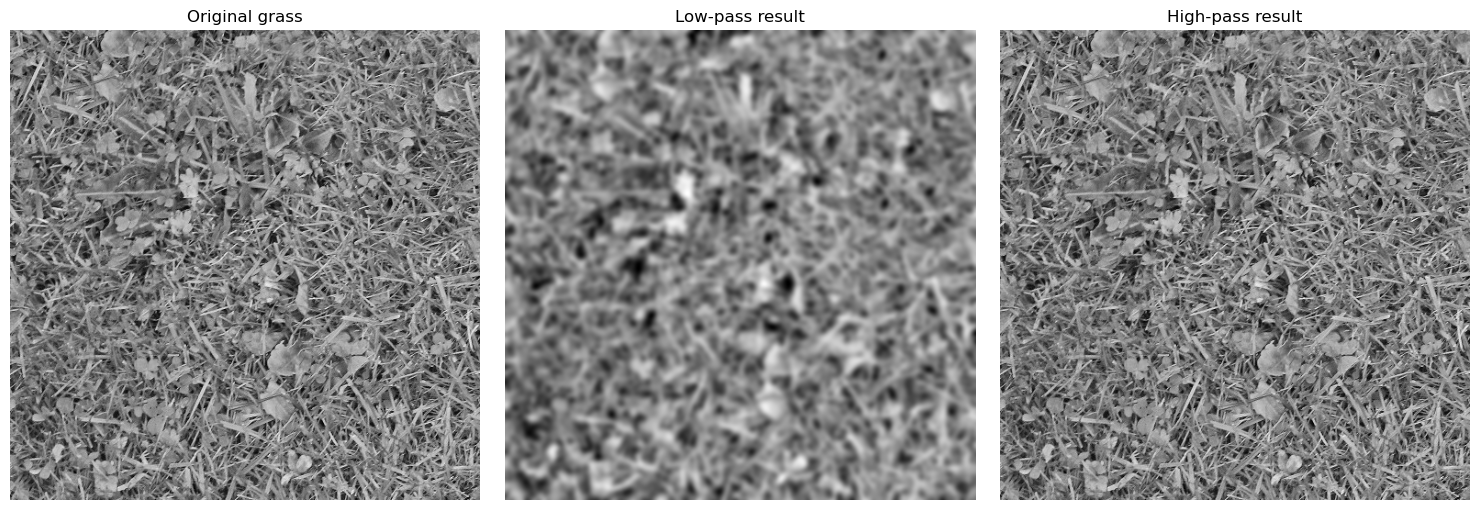

In [43]:
from skimage.filters import gaussian

grass = data.grass()

if grass.ndim == 3:
    R = grass[:, :, 0]
    G = grass[:, :, 1]
    B = grass[:, :, 2]
    grass_gray = 0.2125 * R + 0.7154 * G + 0.0721 * B
else:
    grass_gray = grass

# Low-pass filter:
# Gaussian blur removes high-frequency details
low_pass_img = gaussian(grass_gray, sigma=3)

# High-pass filter:
# subtract the smooth low-frequency image from the original
high_pass_img = grass_gray - low_pass_img


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(grass_gray, cmap="gray")
axes[0].set_title("Original grass")
axes[0].axis("off")

axes[1].imshow(low_pass_img, cmap="gray")
axes[1].set_title("Low-pass result")
axes[1].axis("off")

axes[2].imshow(high_pass_img, cmap="gray")
axes[2].set_title("High-pass result")
axes[2].axis("off")

plt.tight_layout()
plt.show()

**Task 7:** Morphological erosion is an operation used on binary images to shrink white/foreground objects.  
This footprint acts like a small circular probe. During erosion, a pixel remains part of a blob only if the whole disk can fit inside the blob around that pixel. If the disk overlaps the background, that pixel is removed.

The goal of the task is to count how many repeated erosions are needed until there are no foreground pixels

When *eroded.any()* becomes False, it means all blobs have been removed.

So the number of erosions depends on the size and thickness of the generated blobs: larger blobs require more erosions, while smaller blobs disappear faster.

Number of consecutive erosions needed to remove all blobs: 10


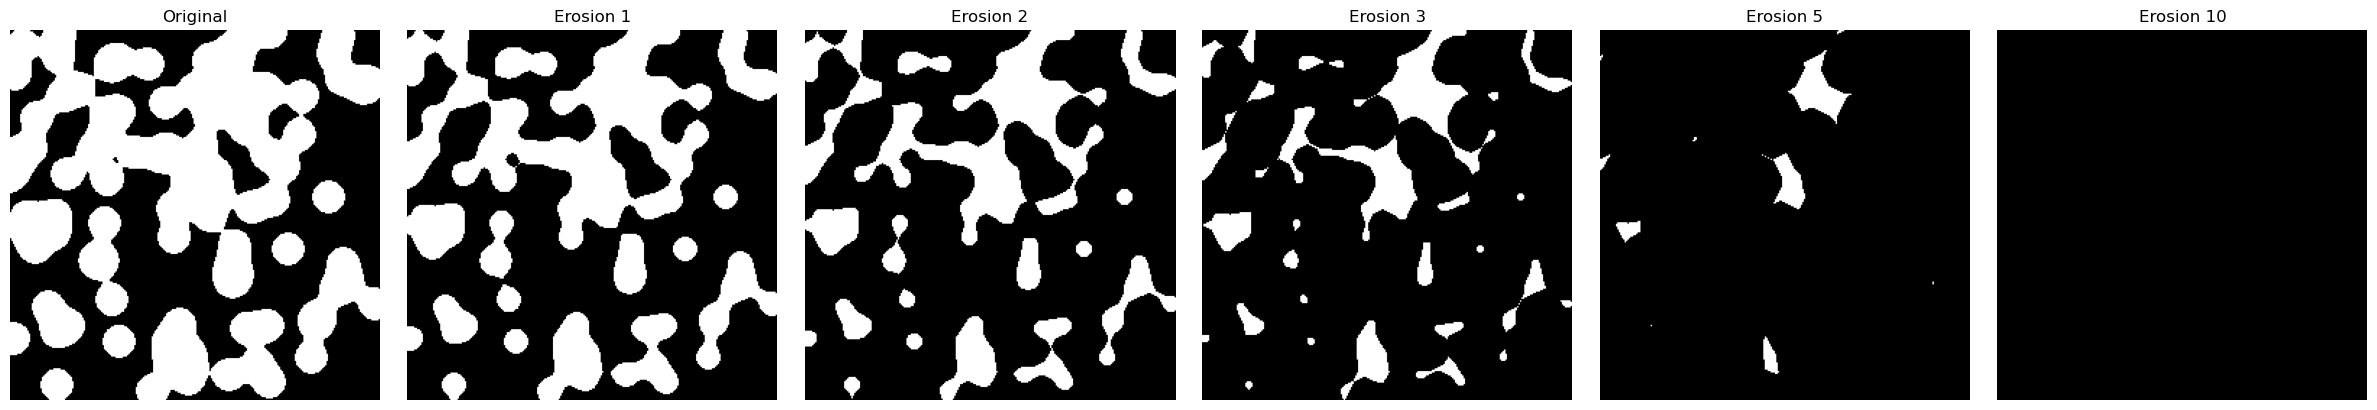

In [45]:
from skimage.data import binary_blobs
from skimage.morphology import erosion, disk


img = binary_blobs(length=256, blob_size_fraction=0.1, volume_fraction=0.5)
footprint = disk(3)
eroded = img.copy()

n_erosions = 0

# Stored some intermediate results for visualization
images = [eroded]
titles = ["Original"]

# Keep applying erosion until no blob pixels remain
while eroded.any():
    eroded = erosion(eroded, footprint=footprint)
    n_erosions += 1

    # Saved only some steps for display, to avoid too many subplots
    if n_erosions in [1, 2, 3, 5, 10] or not eroded.any():
        images.append(eroded.copy())
        titles.append(f"Erosion {n_erosions}")

print(f"Number of consecutive erosions needed to remove all blobs: {n_erosions}")

fig, axes = plt.subplots(1, len(images), figsize=(4 * len(images), 4))

if len(images) == 1:
    axes = [axes]

for ax, im, title in zip(axes, images, titles):
    ax.imshow(im, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()